# Robust MPC full code

In [32]:
# Import all the packages we need
import numpy as np
import pandas as pd
from typing import Optional, Tuple

import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import pickle
from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time

# from pytorch_forecasting.metrics.quantile import QuantileLoss

# For LSTM
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from tqdm import tqdm
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

from sklearn.preprocessing import StandardScaler
import torch.autograd.functional as F

# For TFT
from tqdm import tqdm_notebook as tqdm

import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)


# import functions
from TiDE import TideModule, quantile_loss, TiDE_forward
from sys_model import nominal_model, nominal_model_recur, system_model
from RobustMPC import RMPC_iteration

cuda is available


## Load pre-trained models

### Load nominal model

In [33]:
with open('MPC_controlled_quantile_params_w10_larger_lr.pkl', 'rb') as file:
    nominal_params = pickle.load(file)

# 타입 통일 (Tensor → NumPy)
for key in ['x_min', 'x_max', 'u_min', 'u_max']:
    if isinstance(nominal_params[key], torch.Tensor):
        nominal_params[key] = nominal_params[key].detach().cpu().numpy()

# numpy 기반으로 처리
nominal_params["u_max"] = np.max(nominal_params["u_max"])
nominal_params["u_min"] = np.min(nominal_params["u_min"])

# 모델 로드
nominal_TiDE = nominal_params['model'].to('cpu')
nominal_TiDE.load_state_dict(torch.load('MPC_controlled_quantile_TiDE_w10_larger_lr.pth'))
nominal_TiDE.eval()

window = 10
P = 10
print(f'x_min: {nominal_params["x_min"]}, x_max: {nominal_params["x_max"]}')
print(f'u_min: {nominal_params["u_min"]}, u_max: {nominal_params["u_max"]}')


x_min: [[-2.686839 ]
 [-4.0999618]], x_max: [[2.688875 ]
 [4.1233764]]
u_min: -3.64729380607605, u_max: 3.6125309467315674


### Load tube model

In [34]:
# # Open the pickle file
# with open('controlled_quantile_params_w1_larger_QR.pkl', 'rb') as file:
#     # 2. Load the data from the pickle file
#     tube_params = pickle.load(file)
# # Load nominal TiDE model
# tube_TiDE = tube_params['model'].to("cpu")
# tube_TiDE.load_state_dict(torch.load('controlled_quantile_TiDE_w1_larger_QR.pth'))
# tube_TiDE = tube_TiDE.eval()
# P = 10

# Open the pickle file
with open('controlled_quantile_params_w1_larger_QR_e_no_scale.pkl', 'rb') as file:
    # 2. Load the data from the pickle file
    tube_params = pickle.load(file)
# Load nominal TiDE model
tube_TiDE = tube_params['model'].to("cpu")
tube_TiDE.load_state_dict(torch.load('controlled_quantile_TiDE_w1_larger_QR_e_no_scale.pth'))
tube_TiDE = tube_TiDE.eval()
P = 10
window = 10

### Load reference trajectory

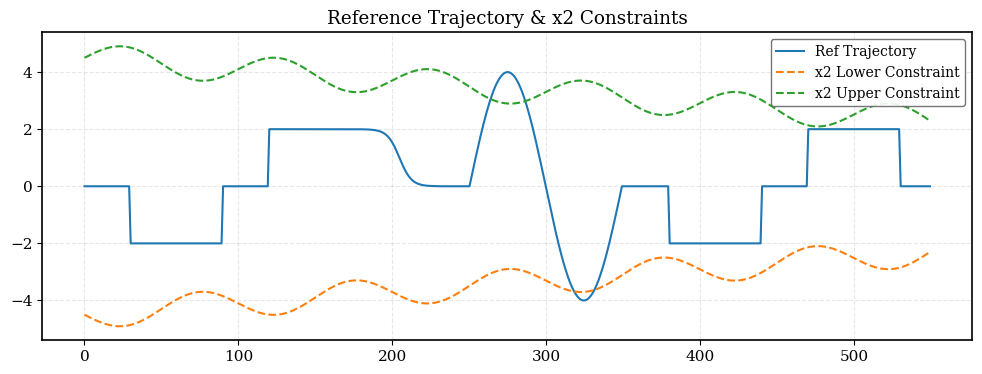

In [35]:
import numpy as np
import torch
import matplotlib.pyplot as plt

scaling = 2
Ref_traj_step = np.repeat(np.array([0, -scaling, -scaling, 0, scaling, scaling]), 30)

def sigmoid(x):
    return 1 / (1 + np.exp(-x / 4))

a = scaling
x = np.linspace(0, 50, 50)
y = -sigmoid(x - 25) * a + scaling
Ref_traj_sigmoid = y

x_sin = np.linspace(0, 2 * np.pi, 100)
y_sin = 2 * scaling * np.sin(x_sin)
Ref_traj_sin = y_sin

Ref_traj = np.concatenate((Ref_traj_step, Ref_traj_sigmoid, np.zeros(20), Ref_traj_sin, Ref_traj_step, np.zeros(20)))
tot_step = len(Ref_traj)

x_constraint = np.linspace(0, tot_step, tot_step)
C_Ref_traj_up  = 4.5 + 0.5 * np.sin(2 * np.pi * x_constraint / 100) - 0.004 * x_constraint
C_Ref_traj_low = -C_Ref_traj_up

plt.figure(figsize=(12, 4))
plt.plot(Ref_traj, label="Ref Trajectory", linestyle='-')
plt.plot(C_Ref_traj_low, label="x2 Lower Constraint", linestyle='--')
plt.plot(C_Ref_traj_up,  label="x2 Upper Constraint", linestyle='--')
plt.legend(loc="upper right")
plt.title("Reference Trajectory & x2 Constraints")
plt.show()



### Objective function with checking constraint

In [36]:
def RMPC_obj_TiDE(u_hat:np.array,
                u_past:np.array,
                x_past: np.array,
                SP_hat:np.array,
                P,
                NN_Nominal,
                tube_model=None,
                error_history=None,
                x_max=None,
                x_min=None,
                u_max=None,
                u_min=None
):
    u_hat = torch.tensor(u_hat.reshape(-1,1), requires_grad=True, dtype=torch.float32)
    u_hat_in = u_hat.unsqueeze(0)
    past_cov = torch.tensor(np.concatenate((x_past,u_past), axis=0),dtype=torch.float32).transpose(1,0).unsqueeze(0)
    x_hat = NN_Nominal([past_cov, u_hat_in, None])

    global x_hat_global
    x_hat_global = x_hat[0,:,:,1]

    x_hat = x_hat[0,:,0,1]
    u_hat_temp = u_hat_in[0,:,0].reshape(-1,1)
    u = u_hat_temp[0].reshape(-1,1)
    u_hat0 = torch.concatenate((u, u_hat_temp))

    Obj = 100 * torch.sum((x_hat - torch.tensor(SP_hat, dtype=torch.float32))**2) + 1 * torch.sum((u_hat0[1:]-u_hat0[0:-1])**2)
    Obj.backward()
    return Obj.item(), u_hat.grad.numpy().reshape(-1)


def x_bound_check(u, u_past, tube_model, error_history, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                  x2_upper_bound=None, x2_lower_bound=None):
    """
    Time-varying constraint on x2 only.
    x2_upper_bound / x2_lower_bound: scalars for the current step (from C_Ref_traj_up/low)
    x1: no constraint (reference tracking only)
    """
    u_hat_in = u.unsqueeze(0)

    u_past_s = -1 + 2 * ((u_past - u_min.reshape(-1,1)) / (u_max-u_min).reshape(-1,1))
    past_cov = torch.tensor(np.concatenate((x_past, u_past_s), axis=0), dtype=torch.float32).transpose(1,0).unsqueeze(0)
    u_hat_s = u_hat_in
    xs_hat = NN_nominal([past_cov, u_hat_s, None])[0,:,:,1]
    x_max_torch = torch.tensor(x_max).reshape(1,-1)
    x_min_torch = torch.tensor(x_min).reshape(1,-1)
    x_hat = ((xs_hat + 1).reshape(-1,2) * 0.5 * ((x_max_torch-x_min_torch).reshape(-1,2)) + x_min_torch.reshape(-1,2))

    if np.all(error_history == 0):
        error_history_np = error_history.transpose(1,0)
    else:
        error_history_np = error_history.transpose(1,0).reshape(-1,2)
    past_cov_error = torch.tensor(np.concatenate((error_history_np, u_past.T), axis=1), dtype=torch.float32).unsqueeze(0)
    past_cov_error_tube = past_cov_error[:, -1:, :]  # tube model은 window=1

    u_max_t = torch.tensor(u_max)
    u_min_t = torch.tensor(u_min)
    u_hat_orig = ((u + 1).reshape(-1,1)*0.5*(u_max_t-u_min_t).reshape(-1,1) + u_min_t.reshape(-1,1)).unsqueeze(0).to(torch.float32)

    error_hat = tube_model([past_cov_error_tube, u_hat_orig, None])[0,:,:,:]

    x2_upper = x_hat[:,1] + error_hat[:,1,2]
    x2_lower = x_hat[:,1] + error_hat[:,1,0]
    x2_upper_max = torch.max(x2_upper)
    x2_lower_min = torch.min(x2_lower)

    # Time-varying x2 bounds
    ub = float(x2_upper_bound) if x2_upper_bound is not None else 3.0
    lb = float(x2_lower_bound) if x2_lower_bound is not None else -3.0

    g3 = ub  - x2_upper_max   # x2 <= ub
    g4 = x2_lower_min - lb    # x2 >= lb  (i.e. x2_lower >= lb)

    g_all = torch.stack([g3, g4]).reshape(1,-1).squeeze()
    return g_all


def x_bound_check_wo_tube(u, u_past, tube_model, error_history, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                           x2_upper_bound=None, x2_lower_bound=None):
    u_hat_in = u.unsqueeze(0)
    u_past_s = -1 + 2 * ((u_past - u_min.reshape(-1,1)) / (u_max-u_min).reshape(-1,1))
    past_cov = torch.tensor(np.concatenate((x_past, u_past_s), axis=0), dtype=torch.float32).transpose(1,0).unsqueeze(0)
    xs_hat = NN_nominal([past_cov, u_hat_in, None])[0,:,:,1]
    x_max_torch = torch.tensor(x_max).reshape(1,-1)
    x_min_torch = torch.tensor(x_min).reshape(1,-1)
    x_hat = ((xs_hat + 1).reshape(-1,2) * 0.5 * ((x_max_torch-x_min_torch).reshape(-1,2)) + x_min_torch.reshape(-1,2))

    x2_hat = x_hat[:,1]
    ub = float(x2_upper_bound) if x2_upper_bound is not None else 3.0
    lb = float(x2_lower_bound) if x2_lower_bound is not None else -3.0

    g3 = ub - x2_hat
    g4 = x2_hat - lb

    g_all = torch.stack([g3, g4]).reshape(1,-1).squeeze()
    return g_all


def x_bound_check_wrapper(u, u_past_s, tube_model, error_history_s, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                           x2_upper_bound=None, x2_lower_bound=None):
    u_hat_s = torch.tensor(u.reshape(-1,1), requires_grad=True, dtype=torch.float32)
    g_jac = F.jacobian(
        lambda uh: x_bound_check(uh, u_past_s, tube_model, error_history_s, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                                  x2_upper_bound, x2_lower_bound),
        u_hat_s, create_graph=True)
    g_all = x_bound_check(u_hat_s, u_past_s, tube_model, error_history_s, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                           x2_upper_bound, x2_lower_bound)
    return g_all.detach().numpy(), g_jac.detach().squeeze().numpy()


def x_bound_check_wrapper_wo_tube(u, u_past_s, tube_model, error_history_s, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                                   x2_upper_bound=None, x2_lower_bound=None):
    u_hat_s = torch.tensor(u.reshape(-1,1), requires_grad=True, dtype=torch.float32)
    g_jac = F.jacobian(
        lambda uh: x_bound_check_wo_tube(uh, u_past_s, tube_model, error_history_s, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                                          x2_upper_bound, x2_lower_bound),
        u_hat_s, create_graph=True)
    g_all = x_bound_check_wo_tube(u_hat_s, u_past_s, tube_model, error_history_s, x_max, x_min, x_past, u_max, u_min, NN_nominal,
                                   x2_upper_bound, x2_lower_bound)
    return g_all.detach().numpy(), g_jac.detach().squeeze().numpy()


def RMPC_obj_TiDE_w_penalty(u_hat:np.array,
                u_past:np.array,
                x_past: np.array,
                SP_hat:np.array,
                P,
                NN_Nominal,
                tube_model,
                error_history,
                x_max,
                x_min,
                u_max,
                u_min,
                x2_upper_bound=None,
                x2_lower_bound=None
):
    u_hat = torch.tensor(u_hat.reshape(-1,1), requires_grad=True, dtype=torch.float32)
    u_hat_in = u_hat.unsqueeze(0)
    past_cov = torch.tensor(np.concatenate((x_past,u_past), axis=0),dtype=torch.float32).transpose(1,0).unsqueeze(0)
    x_hat_all = NN_Nominal([past_cov, u_hat_in, None])

    x_hat = x_hat_all[0,:,0,1]
    u_hat_temp = u_hat_in[0,:,0].reshape(-1,1)
    u = u_hat_temp[0].reshape(-1,1)
    u_hat0 = torch.concatenate((u, u_hat_temp))

    Obj = 100 * torch.sum((x_hat - torch.tensor(SP_hat, dtype=torch.float32))**2) + 1 * torch.sum((u_hat0[1:]-u_hat0[0:-1])**2)

    # x2 예측값을 original scale로 변환 (tube 없이 nominal prediction만 사용)
    x_max_torch = torch.tensor(x_max).reshape(1,-1)
    x_min_torch = torch.tensor(x_min).reshape(1,-1)
    x_hat_orig = ((x_hat_all[0,:,:,1] + 1).reshape(-1,2) * 0.5 * ((x_max_torch-x_min_torch).reshape(-1,2)) + x_min_torch.reshape(-1,2))

    ub = float(x2_upper_bound) if x2_upper_bound is not None else 3.0
    lb = float(x2_lower_bound) if x2_lower_bound is not None else -3.0

    # 각 horizon 스텝별 위반량 합산 (max 대신 sum → 실제 위반 스텝에만 penalty)
    x2_pred = x_hat_orig[:,1]
    g3 = torch.sum(torch.clamp(x2_pred - ub, min=0))   # upper 위반량 합산
    g4 = torch.sum(torch.clamp(lb - x2_pred, min=0))   # lower 위반량 합산

    Obj_w_penalty = Obj + 300 * (g3 + g4)
    Obj_w_penalty.backward()
    return Obj_w_penalty.item(), u_hat.grad.numpy().reshape(-1)


## MPC with soft constraint penalty

In [ ]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(513)

u_hat = np.zeros((P))
x_past = np.zeros((2,window))
u_past = np.zeros((1,window))
error_past = np.zeros((2,window))
x_current = np.zeros((2,1))

K_ac = np.array([[-0.2068,-0.6756]])

class TimeVaryingPenaltyObj:
    def __init__(self, base_obj, c_up_arr, c_low_arr):
        self.base  = base_obj
        self.c_up  = c_up_arr
        self.c_low = c_low_arr
        self.step  = 0

    def __call__(self, u_hat, u_past, x_past, SP_hat, P, NN_Nominal,
                 tube_model, error_history, x_max, x_min, u_max, u_min):
        ub = self.c_up [min(self.step, len(self.c_up )-1)]
        lb = self.c_low[min(self.step, len(self.c_low)-1)]
        return self.base(u_hat, u_past, x_past, SP_hat, P, NN_Nominal,
                         tube_model, error_history, x_max, x_min, u_max, u_min,
                         x2_upper_bound=ub, x2_lower_bound=lb)

penalty_obj_tv = TimeVaryingPenaltyObj(RMPC_obj_TiDE_w_penalty, C_Ref_traj_up, C_Ref_traj_low)

MPC_w_penalty_tube = RMPC_iteration(u_hat=u_hat,
                     x_past=x_past,
                     u_past=u_past,
                     window=window,
                     P=P,
                     x_current=x_current,
                     K_ac=K_ac,
                     sys_params=nominal_params,
                     optim_obj=penalty_obj_tv,
                     include_u_hist=False,
                     NN_model=nominal_TiDE,
                     NN_forward=TiDE_forward,
                     error_past=error_past,
                     constraint=None,
                     tube_model=tube_TiDE,
                     u_tighten=None)

n_steps = len(Ref_traj) - P

step_times = []
for i in range(n_steps):
    t0 = time.time()
    SP_hat = Ref_traj[i:i+P]
    penalty_obj_tv.step = i
    MPC_w_penalty_tube.run_one_step_w_penalty(SP_hat=SP_hat)
    elapsed = time.time() - t0
    step_times.append(elapsed)

    c_up = C_Ref_traj_up[min(i, len(C_Ref_traj_up)-1)]
    c_low = C_Ref_traj_low[min(i, len(C_Ref_traj_low)-1)]
    x2_cur = MPC_w_penalty_tube.real_output[1, -1]
    activated = x2_cur > c_up or x2_cur < c_low

    if i % 50 == 0 or elapsed > 2.0 or activated:
        avg = np.mean(step_times[-10:]) if len(step_times) >= 10 else np.mean(step_times)
        eta = avg * (n_steps - i) / 60
        status = f"[CONSTRAINT {'ON ' if activated else 'OFF'}] x2={x2_cur:.2f} bound=[{c_low:.2f},{c_up:.2f}]"
        print(f"Step {i}/{n_steps} | {elapsed:.2f}s | avg={avg:.2f}s | ETA={eta:.1f}min | {status}")



Step 0/540 | 0.10s | avg=0.10s | ETA=0.9min | [CONSTRAINT OFF] x2=-0.17 bound=[-4.50,4.50]
Step 50/540 | 0.14s | avg=0.11s | ETA=0.9min | [CONSTRAINT OFF] x2=-3.04 bound=[-4.30,4.30]
Step 100/540 | 0.23s | avg=0.14s | ETA=1.0min | [CONSTRAINT OFF] x2=0.17 bound=[-4.10,4.10]
Step 150/540 | 0.10s | avg=0.10s | ETA=0.7min | [CONSTRAINT OFF] x2=2.99 bound=[-3.89,3.89]
Step 200/540 | 0.08s | avg=0.09s | ETA=0.5min | [CONSTRAINT OFF] x2=2.18 bound=[-3.71,3.71]
Step 250/540 | 0.14s | avg=0.21s | ETA=1.0min | [CONSTRAINT OFF] x2=0.09 bound=[-3.48,3.48]
Step 266/540 | 0.47s | avg=0.56s | ETA=2.5min | [CONSTRAINT ON ] x2=3.10 bound=[-3.00,3.00]
Step 267/540 | 0.39s | avg=0.50s | ETA=2.3min | [CONSTRAINT ON ] x2=3.01 bound=[-2.98,2.98]
Step 269/540 | 0.25s | avg=0.45s | ETA=2.0min | [CONSTRAINT ON ] x2=3.06 bound=[-2.95,2.95]
Step 271/540 | 0.53s | avg=0.41s | ETA=1.8min | [CONSTRAINT ON ] x2=2.97 bound=[-2.93,2.93]
Step 276/540 | 0.52s | avg=0.38s | ETA=1.7min | [CONSTRAINT ON ] x2=3.00 bound=[-

ValueError: Per-column arrays must each be 1-dimensional

Saved: mpc_result.csv (540 steps), mpc_step_times.csv (540 steps)


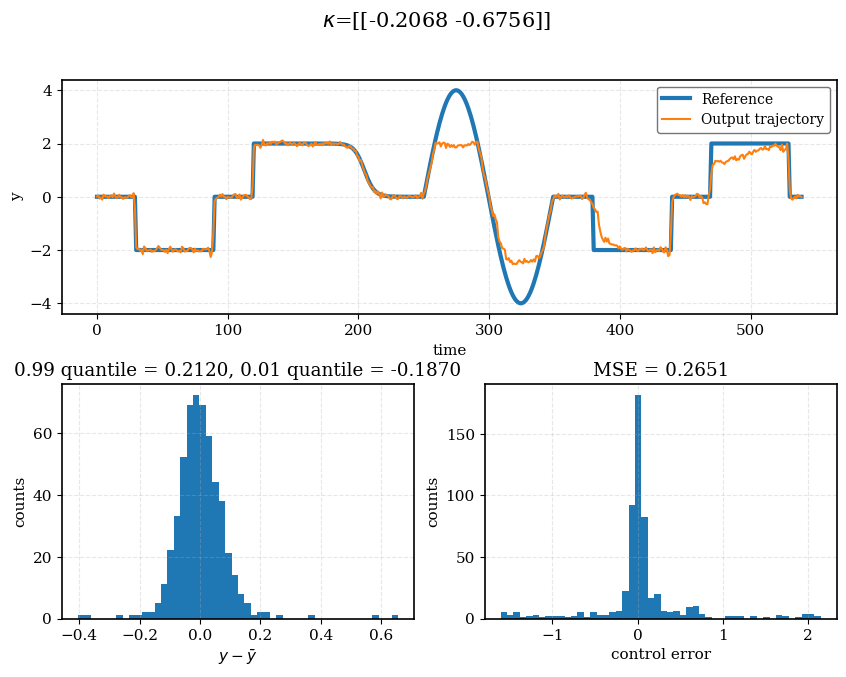

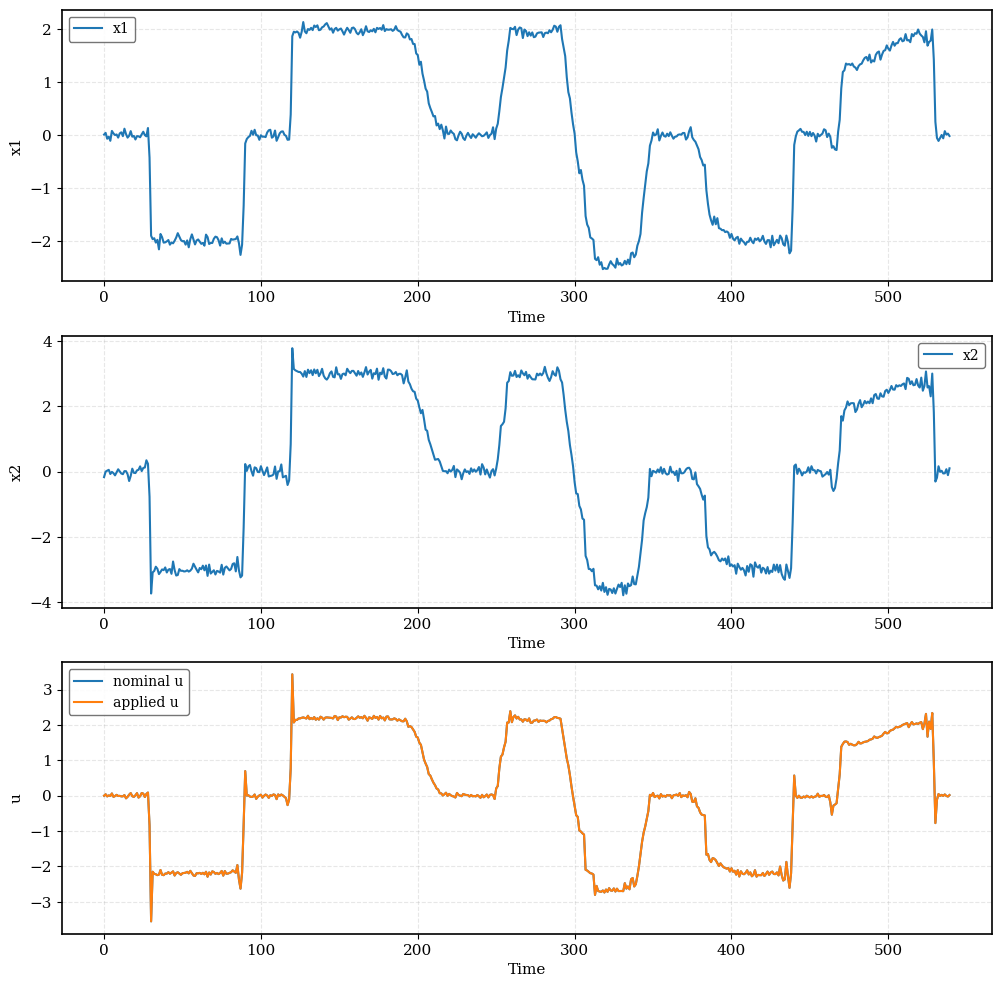


=== MPC Computation Time per Step ===
Mean:   0.2380s
Median: 0.1528s
Std:    0.2729s
Min:    0.0444s
Max:    5.0743s


In [39]:
# =========================
# CSV 저장
# =========================
n_save = MPC_w_penalty_tube.real_output.shape[1]

pd.DataFrame({
    'x1':      MPC_w_penalty_tube.real_output[0, :],
    'x2':      MPC_w_penalty_tube.real_output[1, :],
    'u':       MPC_w_penalty_tube.u_applied_save[:n_save].flatten(),
    'x1_ref':  Ref_traj[:n_save].flatten(),
    'x2_up':   C_Ref_traj_up[:n_save].flatten(),
    'x2_low':  C_Ref_traj_low[:n_save].flatten(),
}).to_csv('mpc_result.csv', index=False)

pd.DataFrame({
    'step': np.arange(len(step_times)),
    'time': step_times,
}).to_csv('mpc_step_times.csv', index=False)

print(f"Saved: mpc_result.csv ({n_save} steps), mpc_step_times.csv ({len(step_times)} steps)")

# =========================
# 기존 플롯
# =========================
MPC_w_penalty_tube.Plot_standard(Ref_traj, n_steps, plot_traj_steps=n_steps, show_constraints=False)
MPC_w_penalty_tube.Plot_input_output(show_constraint=False)

times = np.array(step_times)
print(f'\n=== MPC Computation Time per Step ===')
print(f'Mean:   {times.mean():.4f}s')
print(f'Median: {np.median(times):.4f}s')
print(f'Std:    {times.std():.4f}s')
print(f'Min:    {times.min():.4f}s')
print(f'Max:    {times.max():.4f}s')

ValueError: x and y must have same first dimension, but have shapes (540,) and (124,)

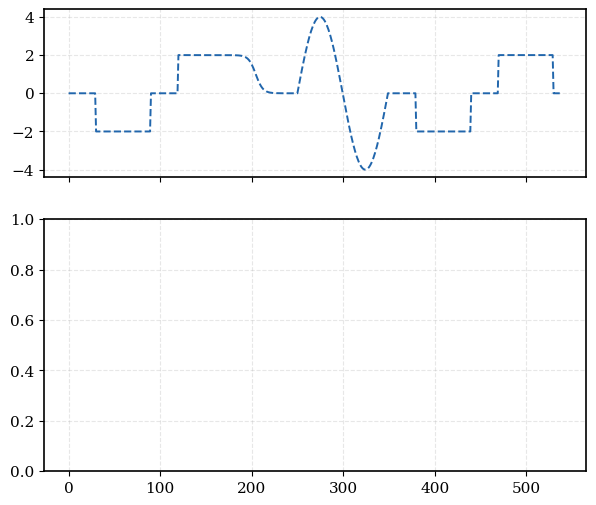

In [ ]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.4',
    'legend.fontsize': 10,
})

C1 = '#2166AC'   # x1 → 파랑
C2 = '#D6604D'   # x2 → 주황-빨강
CU = '#4DAC26'   # u  → 초록
CU2 = '#1A9850'  # applied u → 진초록

fig, axes = plt.subplots(2, 1, figsize=(7, 6),
                         gridspec_kw={'height_ratios': [2, 3]},
                         sharex=True)

# ── (a): x1 tracking + x2 constraint ──
ax1 = axes[0]

ax1.plot(np.arange(n_steps), Ref_traj[:n_steps],
         color=C1, lw=1.4, ls='--', label=r'reference for $x^1$')
ax1.plot(np.arange(n_steps), MPC_w_penalty_tube.real_output[0, :],
         color=C1, lw=1.4, label=r'$x^1$')
ax1.plot(np.arange(n_steps), MPC_w_penalty_tube.real_output[1, :],
         color=C2, lw=1.4, label=r'$x^2$')
ax1.plot(np.arange(n_steps), C_Ref_traj_up[:n_steps],  color=C2, lw=1.2, ls='--')
ax1.plot(np.arange(n_steps), C_Ref_traj_low[:n_steps], color=C2, lw=1.2, ls='--')
ax1.fill_between(np.arange(n_steps), C_Ref_traj_low[:n_steps], C_Ref_traj_up[:n_steps],
                 color=C2, alpha=0.15, label=r'constraint for $x^2$')

ax1.set_ylabel(r'$x^1,\ x^2$')
ax1.legend(loc='upper right', ncol=2, framealpha=0.9, edgecolor='0.4')
ax1.text(0.01, 0.93, '(a)', transform=ax1.transAxes, fontsize=11, va='top')

# ── (b): control input ──
ax2 = axes[1]

ax2.step(np.arange(len(MPC_w_penalty_tube.nominal_u)),
         MPC_w_penalty_tube.nominal_u,
         color=CU, lw=1.4, where='post', label=r'nominal $u$')
ax2.step(np.arange(len(MPC_w_penalty_tube.u_applied_save)),
         MPC_w_penalty_tube.u_applied_save,
         color=CU2, lw=1.4, where='post', alpha=0.8, label=r'applied $u$')
ax2.axhline(y=nominal_params['u_max'], color='gray', lw=1.0, ls='--', label=r'$u$ bounds')
ax2.axhline(y=nominal_params['u_min'], color='gray', lw=1.0, ls='--')

ax2.set_ylabel(r'$u$')
ax2.set_xlabel('Timestep')
ax2.legend(loc='upper right', ncol=2, framealpha=0.9, edgecolor='0.4')
ax2.text(0.01, 0.93, '(b)', transform=ax2.transAxes, fontsize=11, va='top')

plt.tight_layout()
plt.savefig('mpc_result.pdf', bbox_inches='tight', dpi=300)
plt.show()